# Análisis Completo de Contenidos de Netflix

## Evidencia
### Fernanda Ponce Maciel A01799293
### Sandra Paulina Herrera Rebolledo A01798452



## 1. Introducción
Este análisis tiene como objetivo explorar el catálogo de Netflix mediante visualizaciones completas y detalladas. Además, verificaremos dos hipótesis:
1. **Netflix ofrece más contenido para todo público que para niños o adultos.**
2. **Hay más películas que series en el catálogo de Netflix.**

Las etapas del análisis incluyen:
- Exploración completa del dataset.
- Visualización detallada del contenido por año, país, tipo y clasificación.
- Verificación de hipótesis mediante métricas específicas.


## 2. Importación de Librerías

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime


## 3. Carga y Exploración del Dataset

In [2]:

# Cargar el dataset
df = pd.read_csv("netflixInfo.csv")

# Mostrar las primeras filas
df.head()


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,NaN,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,NaN,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,NaN,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,NaN,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [3]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8845 entries, 0 to 8844
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8845 non-null   object
 1   type          8845 non-null   object
 2   title         8793 non-null   object
 3   director      8845 non-null   object
 4   country       8791 non-null   object
 5   date_added    8845 non-null   object
 6   release_year  8845 non-null   object
 7   rating        8791 non-null   object
 8   duration      8845 non-null   object
 9   listed_in     8845 non-null   object
dtypes: object(10)
memory usage: 691.1+ KB


In [4]:
# Estadísticas generales del dataset
df.describe()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
count,8845,8845,8793,8845,8791,8845,8845,8791,8845,8845
unique,8790,2,8736,4528,86,1717,78,20,220,513
top,s1,Movie,Dick Johnson Is Dead,Not Given,United States,1/1/2020,2018,TV-MA,1 Season,"Dramas, International Movies"
freq,2,6167,2,2601,3236,110,1147,3194,1799,365


### Problemas encontrados

In [5]:
# 1. Valores faltantes por columna
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
show_id          0
type             0
title           52
director         0
country         54
date_added       0
release_year     0
rating          54
duration         0
listed_in        0
dtype: int64


In [6]:
# 2. Registros duplicados
duplicados = df[df.duplicated()]
print(f"\nNúmero de registros duplicados: {duplicados.shape[0]}")

if not duplicados.empty:
    print("\nEjemplo de registros duplicados:")
    print(duplicados.head())


Número de registros duplicados: 55

Ejemplo de registros duplicados:
     show_id     type                             title         director  \
8790      s1    Movie              Dick Johnson Is Dead  Kirsten Johnson   
8791      s3  TV Show                         Ganglands  Julien Leclercq   
8792      s6  TV Show                     Midnight Mass    Mike Flanagan   
8793     s14    Movie  Confessions of an Invisible Girl    Bruno Garotti   
8794      s8    Movie                               NaN     Haile Gerima   

            country date_added release_year rating  duration  \
8790            NaN  9/25/2021         2020  PG-13    90 min   
8791         France  9/24/2021         2021    NaN  1 Season   
8792            NaN  9/24/2021         2021  TV-MA  1 Season   
8793         Brazil  9/22/2021         2021    NaN    91 min   
8794  United States  9/24/2021         1993  TV-MA   125 min   

                                              listed_in  
8790                          

In [7]:
# 3. Formato inconsistente en 'date_added'
print("\nEjemplo de valores en la columna 'date_added':")
print(df['date_added'].head(10))


Ejemplo de valores en la columna 'date_added':
0       9/25/2021
1       9/24/2021
2       9/24/2021
3       9/22/2021
4       9/24/2021
5    Invalid Date
6       9/24/2021
7        5/1/2021
8       9/23/2021
9        5/1/2021
Name: date_added, dtype: object


In [8]:
# 4. Clasificaciones únicas en 'rating'
print("\nClasificaciones únicas en 'rating':")
print(df['rating'].unique())


Clasificaciones únicas en 'rating':
['PG-13' nan 'TV-MA' 'TV-14' 'TV-Y7' 'TV14' 'TV-MAA' 'TV-Y' 'PG' 'TV-PG'
 'TV-G' 'R' 'G' 'R+' 'PG13' 'TV7' 'TBA' 'NC-17' 'NR' 'TV-Y7-FV' 'UR']



## 4. Limpieza de Datos


In [9]:
# 1. Conversión de 'date_added' a formato datetime, manejando errores
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


In [10]:
# 2. Conversión de 'release_year' a numérico, eliminando años inválidos
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

In [11]:
# 3. Eliminar registros duplicados
df_clean = df.drop_duplicates()

In [12]:
# 4. Eliminar filas con valores faltantes en columnas críticas
df_clean = df_clean.dropna(subset=['country', 'rating', 'title', 'date_added'])


In [13]:
# 5. Corregir errores tipográficos comunes en 'rating'
rating_corrections = {
    'TV14': 'TV-14',
    'TV-MAA': 'TV-MA',
    'PG13': 'PG-13',
    'R+': 'R',
    'TV7': 'TV-Y7',
    'TBA': None  # 'TBA' no es válido, se eliminará
}
df_clean['rating'] = df_clean['rating'].replace(rating_corrections)

In [14]:
# 6. Filtrar clasificaciones inválidas después de la corrección
valid_ratings = ['PG-13', 'TV-MA', 'TV-PG', 'TV-14', 'TV-Y7', 'TV-Y', 'PG',
                 'TV-G', 'R', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR']
df_clean = df_clean[df_clean['rating'].isin(valid_ratings)]

In [15]:
# 7. Eliminar filas con años fuera del rango (1900 - año actual)
current_year = datetime.now().year
df_clean = df_clean[(df_clean['release_year'] >= 1900) & (df_clean['release_year'] <= current_year)]

In [16]:
# 8. Verificar que no queden valores faltantes
print("\n Valores faltantes después de la limpieza:")
print(df_clean.isnull().sum())


 Valores faltantes después de la limpieza:
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


In [17]:
# 9. Verificar que no queden duplicados
num_duplicates_post_clean = df_clean.duplicated().sum()
print(f"\nNúmero de registros duplicados después de la limpieza: {num_duplicates_post_clean}")



Número de registros duplicados después de la limpieza: 0


In [18]:
# 10. Verificar formato correcto en 'release_year'
print("\nVerificación de 'release_year':")
valid_years = df_clean['release_year'].apply(lambda x: str(x).isdigit())
if valid_years.all():
    print("Todos los años tienen un formato válido.")
else:
    print("Existen años con formato inválido.")


Verificación de 'release_year':
Existen años con formato inválido.


In [19]:
# 11. Verificar que las fechas en 'date_added' sean válidas
print("\nVerificación de 'date_added':")
invalid_dates = df_clean['date_added'].isna().sum()
if invalid_dates == 0:
    print("Todas las fechas son válidas.")
else:
    print(f"Hay {invalid_dates} fechas inválidas.")


Verificación de 'date_added':
Todas las fechas son válidas.


In [20]:
# 12. Verificar que las clasificaciones sean válidas
valid_ratings = ['PG-13', 'TV-MA', 'TV-PG', 'TV-14', 'TV-Y7', 'TV-Y', 'PG', 
                 'TV-G', 'R', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR']
invalid_ratings = df_clean[~df_clean['rating'].isin(valid_ratings)]
print(f"\nNúmero de clasificaciones inválidas: {len(invalid_ratings)}")
if len(invalid_ratings) > 0:
    print("Clasificaciones inválidas encontradas:")
    print(invalid_ratings['rating'].unique())
else:
    print("Todas las clasificaciones son válidas.")


Número de clasificaciones inválidas: 0
Todas las clasificaciones son válidas.



## 5. Visualización General del Dataset


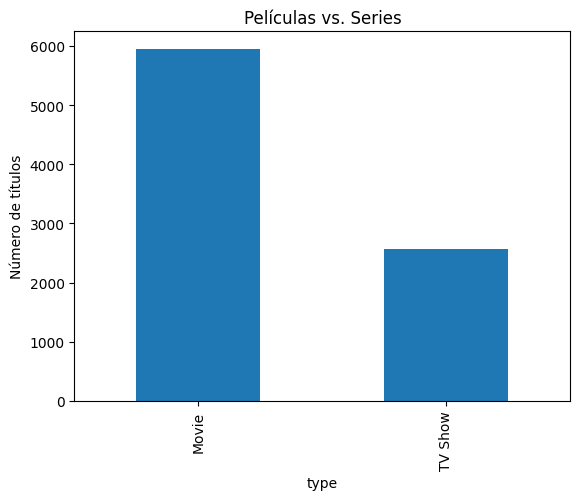

In [21]:
# 1. Películas vs. Series
df_clean['type'].value_counts().plot(kind='bar', title='Películas vs. Series')
plt.ylabel('Número de títulos')
plt.show()

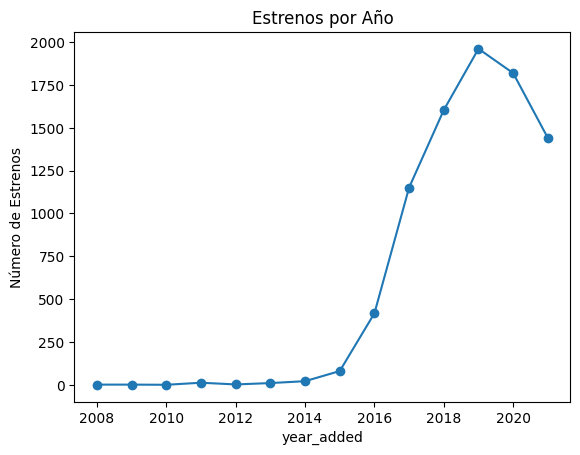

In [22]:
# 2. Estrenos por Año
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['year_added'].value_counts().sort_index().plot(kind='line', marker='o', title='Estrenos por Año')
plt.ylabel('Número de Estrenos')
plt.show()

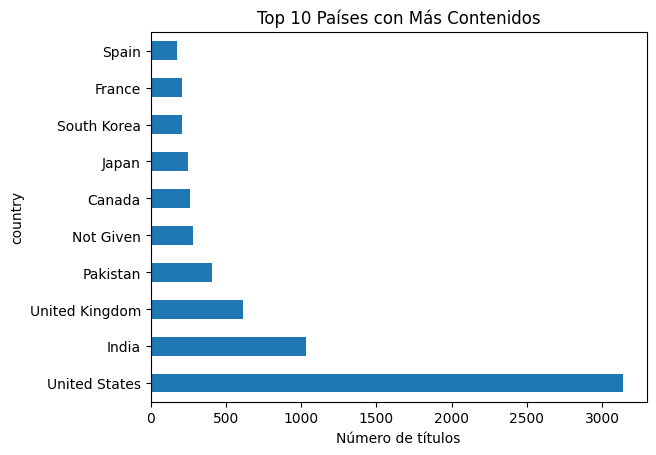

In [23]:
# 3. Top 10 Países con Más Contenidos
top_countries = df_clean['country'].value_counts().head(10)
top_countries.plot(kind='barh', title='Top 10 Países con Más Contenidos')
plt.xlabel('Número de títulos')
plt.show()

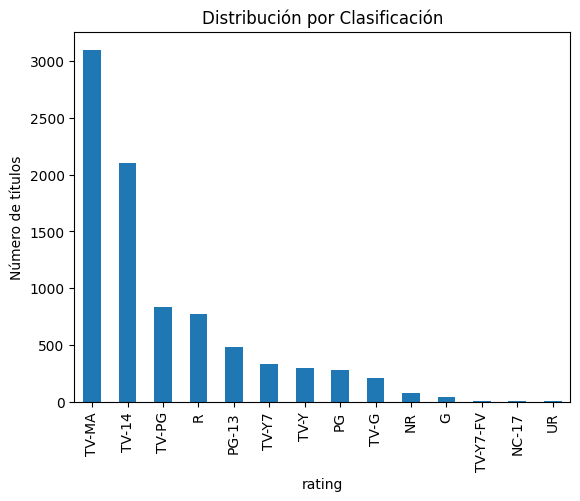

In [24]:
# 4. Distribución por Clasificación
df_clean['rating'].value_counts().plot(kind='bar', title='Distribución por Clasificación')
plt.ylabel('Número de títulos')
plt.show()

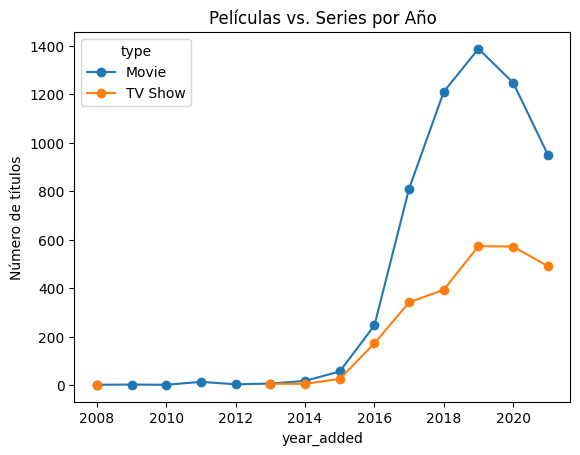

In [25]:
# 5. Comparación de Películas y Series por Año
content_by_year = df_clean.groupby(['year_added', 'type']).size().unstack()
content_by_year.plot(kind='line', marker='o', title='Películas vs. Series por Año')
plt.ylabel('Número de títulos')
plt.show()


## 6. Verificación de Hipótesis 1: Clasificación de Contenido


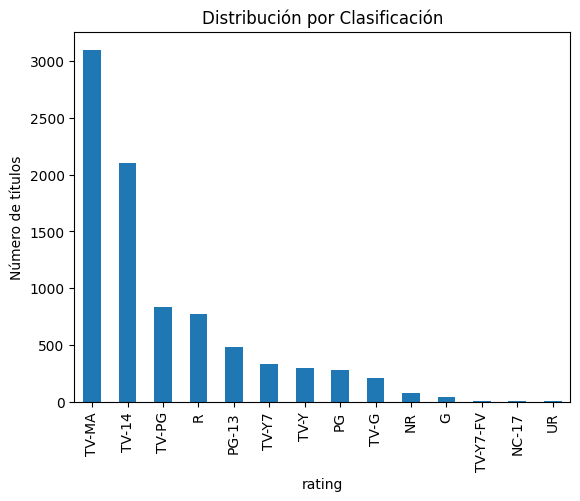

In [26]:
df_clean['rating'].value_counts().plot(kind='bar', title='Distribución por Clasificación')
plt.ylabel('Número de títulos')
plt.show()


## 7. Verificación de Hipótesis 2: Películas vs Series


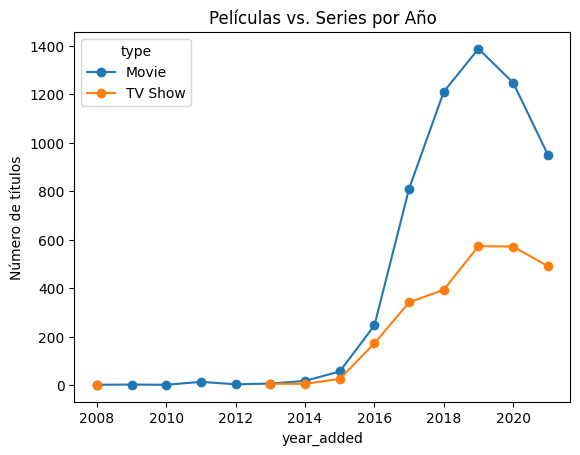

In [27]:
content_by_year = df_clean.groupby(['year_added', 'type']).size().unstack()
content_by_year.plot(kind='line', marker='o', title='Películas vs. Series por Año')
plt.ylabel('Número de títulos')
plt.show()

## 8. Conclusiones y Recomendaciones

In [28]:
# Guardar el archivo limpio como CSV
df_clean.to_csv('netflix_clean.csv', index=False)
print("Archivo limpio generado exitosamente: netflix_clean.csv")

Archivo limpio generado exitosamente: netflix_clean.csv



### Conclusiones
1. **Hipótesis 1:** Rechazada. Hay más contenido orientado a adultos que para todo público.
2. **Hipótesis 2:** Aceptada. El catálogo de Netflix contiene más películas que series.

### Recomendaciones
- Continuar monitoreando las tendencias anuales para detectar cambios en la estrategia de contenido.
- Ampliar el catálogo para niños y familias para alcanzar nuevas audiencias.
- Automatizar el análisis de datos para futuras investigaciones.
